In [2]:
import statistics as stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [164]:
# reading in datasets
pres = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")

sen = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")

house = pd.read_csv("4-US_Election_2020/house_candidate.csv")


In [ ]:
# getting prop democrat and prop republican for each state
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in pres.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
pres_prop = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Winner": winner})

display(pres_prop)

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner
0,Alabama,0.365707,0.620310,0.013984,REP
1,Alaska,0.391993,0.485228,0.122779,REP
2,Arizona,0.493647,0.490560,0.015793,DEM
3,Arkansas,0.347751,0.623957,0.028292,REP
4,California,0.634992,0.343278,0.021730,DEM
5,Colorado,0.554000,0.418983,0.027017,DEM
6,Connecticut,0.592387,0.392095,0.015518,DEM
7,Delaware,0.587822,0.398014,0.014164,DEM
8,District of Columbia,0.921497,0.053973,0.024530,DEM
9,Florida,0.478615,0.512198,0.009187,REP


In [158]:
# getting swing states 
pres_prop["margin"] = pres_prop["Proportion_Democrat"] - pres_prop["Proportion_Republican"]
pres_prop["margin_abs"] = abs(pres_prop["margin"])
swing = pres_prop.query("margin_abs <= 0.05")
display(swing)

swing_list = swing["State"].tolist()
swing_list

swing_winner = swing[["State", "Winner"]]
display(swing_winner)

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner,margin,margin_abs
2,Arizona,0.493647,0.490560,0.015793,DEM,0.003087,0.003087
9,Florida,0.478615,0.512198,0.009187,REP,-0.033584,0.033584
10,Georgia,0.494953,0.492596,0.012451,DEM,0.002357,0.002357
22,Michigan,0.506208,0.478373,0.015419,DEM,0.027835,0.027835
28,Nevada,0.500568,0.476662,0.022770,DEM,0.023905,0.023905
33,North Carolina,0.485862,0.499343,0.014794,REP,-0.013481,0.013481
38,Pennsylvania,0.499609,0.487818,0.012573,DEM,0.011792,0.011792
49,Wisconsin,0.494540,0.488290,0.017170,DEM,0.006250,0.006250


,State,Winner
2,Arizona,DEM
9,Florida,REP
10,Georgia,DEM
22,Michigan,DEM
28,Nevada,DEM
33,North Carolina,REP
38,Pennsylvania,DEM
49,Wisconsin,DEM


In [111]:
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in sen.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
sen_prop = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Senator_Party": winner})

display(sen_prop)

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Senator_Party
0,Alabama,0.745786,0.249344,0.004869,DEM
1,Alaska,0.590108,0.294475,0.115417,DEM
2,Arizona,0.173511,0.825695,0.000795,REP
3,Arkansas,0.000000,0.228876,0.771124,IND
4,Colorado,0.350723,0.589283,0.059994,REP
5,Delaware,0.298814,0.631578,0.069608,REP
6,Georgia,0.405144,0.544882,0.049975,REP
7,Idaho,0.834971,0.052484,0.112545,DEM
8,Illinois,0.210579,0.625000,0.164421,REP
9,Iowa,0.513389,0.414488,0.072122,DEM


In [ ]:
# filtering for swing states 
sen_swing = sen_prop.query("State in @swing_list")
display(sen_swing)



,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Senator_Party
2,Arizona,0.173511,0.825695,0.000795,REP
6,Georgia,0.405144,0.544882,0.049975,REP
15,Michigan,0.529049,0.425138,0.045813,DEM
23,North Carolina,0.423432,0.466471,0.110097,REP


In [ ]:
#Data Cleaning House
states_list = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California",
    "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
    "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
    "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "West Virginia", "Washington", "Virginia", "Wisconsin", "Wyoming"
]
States = []

for district in house["district"]:
    for index in range(len(states_list)):
        if states_list[index] in district:
            States.append(states_list[index])
            break
    else:
        States.append("None")
        

house["States"] = States


,district,candidate,party,total_votes,won,States
0,Delaware at large,Lisa Blunt Rochester,DEM,281382,True,Delaware
1,Delaware at large,Lee Murphy,REP,196392,False,Delaware
2,Delaware at large,Catherine Purcell,IND,6682,False,Delaware
3,Delaware at large,David Rogers,LIB,3814,False,Delaware
4,Florida’s 1st district,Matt Gaetz,REP,283352,True,Florida
...,...,...,...,...,...,...
1210,California’s 21st district,TJ Cox,DEM,84406,False,California
1211,California’s 25th district,Mike Garcia,REP,169638,True,California
1212,California’s 25th district,Christy Smith,DEM,169305,False,California
1213,California’s 39th district,Young Kim,REP,173946,True,California


In [97]:
house_winners_agg = house.query("won == True")
display(house_winners_agg)

states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in house_winners_agg.groupby("States"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for party in state_data["party"]: #loops through "total_votes" and "party" for each state
        total = total + 1 #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + 1
        elif party == "REP":
            rep = rep + 1
        else:
            ind = ind + 1
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    elif prop_dems == prop_reps:
        win = "TIE"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
house_prop = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "House_Majority": winner})

display(house_prop)

,district,candidate,party,total_votes,won,States
0,Delaware at large,Lisa Blunt Rochester,DEM,281382,True,Delaware
4,Florida’s 1st district,Matt Gaetz,REP,283352,True,Florida
7,Florida’s 2nd district,Neal Dunn,REP,305337,True,Florida
9,Florida’s 3rd district,Kat Cammack,REP,223075,True,Florida
11,Florida’s 4th district,John Rutherford,REP,308497,True,Florida
...,...,...,...,...,...,...
1203,Connecticut’s 5th district,Jahana Hayes,DEM,192484,True,Connecticut
1206,United States’s 0th district,The Democratic candidate,DEM,77138263,True,None
1209,California’s 21st district,David Valadao,REP,85928,True,California
1211,California’s 25th district,Mike Garcia,REP,169638,True,California


,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,House_Majority
0,Alabama,0.142857,0.857143,0.0,REP
1,Alaska,0.000000,1.000000,0.0,REP
2,Arizona,0.555556,0.444444,0.0,DEM
3,Arkansas,0.000000,1.000000,0.0,REP
4,California,0.792453,0.207547,0.0,DEM
5,Colorado,0.571429,0.428571,0.0,DEM
6,Connecticut,1.000000,0.000000,0.0,DEM
7,Delaware,1.000000,0.000000,0.0,DEM
8,Florida,0.407407,0.592593,0.0,REP
9,Georgia,0.428571,0.571429,0.0,REP


In [98]:
# filtering for swing states 
house_swing = house_prop.query("State in @swing_list")
display(house_swing)

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,House_Majority
2,Arizona,0.555556,0.444444,0.0,DEM
8,Florida,0.407407,0.592593,0.0,REP
9,Georgia,0.428571,0.571429,0.0,REP
21,Michigan,0.500000,0.500000,0.0,TIE
27,Nevada,0.750000,0.250000,0.0,DEM
33,North Carolina,0.384615,0.615385,0.0,REP
38,Pennsylvania,0.500000,0.500000,0.0,TIE
49,Wisconsin,0.375000,0.625000,0.0,REP


In [165]:
# merging senate, house, and presidential dataframes for swing states together 
swing_sen_pres = pd.merge(left = swing[["State","Winner"]], 
    right = sen_swing[["State", "Senator_Party"]], 
    how = "left", on = "State")

display(swing_sen_pres)

merged = pd.merge(left = swing_sen_pres, 
    right = house_prop[["State", "House_Majority"]], 
    how = "left", on = "State")

merged

,State,Winner,Senator_Party
0,Arizona,DEM,REP
1,Florida,REP,NaN
2,Georgia,DEM,REP
3,Michigan,DEM,DEM
4,Nevada,DEM,NaN
5,North Carolina,REP,REP
6,Pennsylvania,DEM,NaN
7,Wisconsin,DEM,NaN


,State,Winner,Senator_Party,House_Majority
0,Arizona,DEM,REP,DEM
1,Florida,REP,NaN,REP
2,Georgia,DEM,REP,REP
3,Michigan,DEM,DEM,TIE
4,Nevada,DEM,NaN,DEM
5,North Carolina,REP,REP,REP
6,Pennsylvania,DEM,NaN,TIE
7,Wisconsin,DEM,NaN,REP


In [160]:
# getting number of matches between each pairwise comparison
pres_sen_match = merged.query("Winner == Senator_Party")
n_pres_sen = len(pres_sen_match)
prop_pres_sen = n_pres_sen/4
print(prop_pres_sen)

pres_house_match = merged.query("Winner == House_Majority")
n_pres_house = len(pres_house_match)
prop_pres_house = n_pres_house/8
print(prop_pres_house)

all_match  = merged.query("Winner == Senator_Party == House_Majority")
n_all_match = len(all_match)
prop_all = n_all_match/8
print(prop_all)

0.5
0.5
0.125


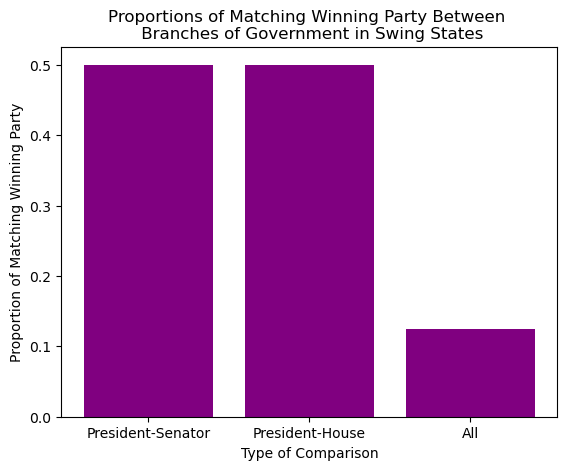

In [163]:
match_cats = ["President-Senator", "President-House", "All"]
match_list = [prop_pres_sen, prop_pres_house, prop_all]

plt.bar(x = match_cats, height = match_list, color = "purple")
plt.xlabel("Type of Comparison")
plt.ylabel("Proportion of Matching Winning Party")
plt.title("Proportions of Matching Winning Party Between \n Branches of Government in Swing States")
plt.show()

In [129]:
# merging senate, house, and presidential dataframes for all  states together 
sen_pres = pd.merge(left = pres_prop[["State", "margin", "Winner"]], 
    right = sen_prop[["State", "Proportion_Democrat", "Proportion_Republican"]], 
    how = "left", on = "State")

all_merged = pd.merge(left = sen_pres, 
    right = house_prop[["State", "Proportion_Democrat", "Proportion_Republican"]], 
    how = "left", on = "State")

all_merged = all_merged.rename(columns={
    "Proportion_Democrat_x": "prop_dem_sen",
    "Proportion_Republican_x": "prop_rep_sen",
    "Proportion_Democrat_y": "prop_dem_house",
    "Proportion_Republican_y": "prop_rep_house",
})

display(all_merged)

all_merged2 = all_merged.query("prop_dem_house == prop_dem_house")
all_merged2

,State,margin,Winner,prop_dem_sen,prop_rep_sen,prop_dem_house,prop_rep_house
0,Alabama,-0.254603,REP,0.745786,0.249344,0.142857,0.857143
1,Alaska,-0.093235,REP,0.590108,0.294475,0.000000,1.000000
2,Arizona,0.003087,DEM,0.173511,0.825695,0.555556,0.444444
3,Arkansas,-0.276207,REP,0.000000,0.228876,0.000000,1.000000
4,California,0.291714,DEM,NaN,NaN,0.792453,0.207547
5,Colorado,0.135017,DEM,0.350723,0.589283,0.571429,0.428571
6,Connecticut,0.200292,DEM,NaN,NaN,1.000000,0.000000
7,Delaware,0.189808,DEM,0.298814,0.631578,1.000000,0.000000
8,District of Columbia,0.867524,DEM,NaN,NaN,NaN,NaN
9,Florida,-0.033584,REP,NaN,NaN,0.407407,0.592593


,State,margin,Winner,prop_dem_sen,prop_rep_sen,prop_dem_house,prop_rep_house
0,Alabama,-0.254603,REP,0.745786,0.249344,0.142857,0.857143
1,Alaska,-0.093235,REP,0.590108,0.294475,0.000000,1.000000
2,Arizona,0.003087,DEM,0.173511,0.825695,0.555556,0.444444
3,Arkansas,-0.276207,REP,0.000000,0.228876,0.000000,1.000000
4,California,0.291714,DEM,NaN,NaN,0.792453,0.207547
5,Colorado,0.135017,DEM,0.350723,0.589283,0.571429,0.428571
6,Connecticut,0.200292,DEM,NaN,NaN,1.000000,0.000000
7,Delaware,0.189808,DEM,0.298814,0.631578,1.000000,0.000000
9,Florida,-0.033584,REP,NaN,NaN,0.407407,0.592593
10,Georgia,0.002357,DEM,0.405144,0.544882,0.428571,0.571429
